In [1]:
import os
# Disable tokenizers parallelism
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

In [2]:
!pip install datasets evaluate transformers[sentencepiece]
!pip install accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.2.1
    Uninstalling accelerate-1.2.1:
      Successfully uninstalled accelerate-1.2.1


In [3]:
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding
import evaluate
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from torch.cuda import amp
from transformers import AutoModel, AutoTokenizer,AutoConfig
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score
import torch
import warnings
import random
warnings.filterwarnings('ignore')
from collections import defaultdict
import torch.nn as nn
from transformers import get_scheduler
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from collections import defaultdict
import gc
gc.enable()


In [4]:
def set_random_seed(random_seed):
    random.seed(random_seed)
    np.random.seed(random_seed)
    os.environ["PYTHONHASHSEED"] = str(random_seed)

    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)

    torch.backends.cudnn.deterministic = True

In [5]:
df = pd.read_csv("/kaggle/input/bengali-pharmaceutical-reviews/LargePharmaVal.csv")

In [6]:
df

,Reviews,category,Label,Length,Word Count
0,চকলেট নিয়ে খুব হতাশ। এক্সপায়ার ডেট শেষ আর অত...,Random/Misc,1,66,11
1,পঁচিশটা অর্ডার করেছিলাম পেয়েছি পঞ্চাশটা সাথে ...,medical_kits,4,183,32
2,সুন্দর প্যাকেজিং করে দিয়েছে! ১০০% অরিজিনাল প্...,womens_item,5,110,15
3,আমি কেন অনলাইনে প্রডাক্ট ক্রয় করলাম ভাই? গ্লোব...,medicines,2,107,18
4,ডেলিভারি একটু দেরি হলেও মাল ভালো। শ্যাম্পু প্র...,womens_item,4,92,15
...,...,...,...,...,...
9510,একদম নিম্ন মানের নেবুলাইজার দিয়ে ঠকালেন। মার্...,medical_kits,1,64,11
9511,"প্রথম কথা, এটা আইসক্রিম ফ্লেভার না, মেনথল/মিন্...",adult_items,1,375,61
9512,😭😭 কি মারাত্মক মাস্ক! মানসম্মত না আর সাইজ ছোট ...,medical_kits,1,53,10
9513,যা ছিল আমার ইচ্ছায় মোটামুটি সব দিয়েছেন সেলার। ...,medicines,4,135,22


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9515 entries, 0 to 9514
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Reviews     9515 non-null   object
 1   category    9515 non-null   object
 2   Label       9515 non-null   int64 
 3   Length      9515 non-null   int64 
 4   Word Count  9515 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 371.8+ KB


In [8]:
df.Label.value_counts()

Label
5    2238
1    2199
4    1989
2    1563
3    1526
Name: count, dtype: int64

In [9]:
df['Label'] = df['Label'].map({1: 0, 2: 1, 3: 2, 4: 3, 5: 4})
print(df['Label'].value_counts()) 

Label
4    2238
0    2199
3    1989
1    1563
2    1526
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

# Step 1: Split the data into train and temp (test + validation) sets
train_data, temp_data = train_test_split(df, test_size=0.3, stratify=df['Label'], random_state=1)

# Step 2: Split the temp set into validation and test sets (10% validation, 20% test)
val_data, test_data = train_test_split(temp_data, test_size=2/3, stratify=temp_data['Label'], random_state=1)

In [11]:
train_data.to_csv("/kaggle/working/train_data.csv", index=False)
val_data.to_csv("/kaggle/working/val_data.csv", index=False)
test_data.to_csv("/kaggle/working/test_data.csv", index=False)

In [12]:
train_data.shape, val_data.shape

((6660, 5), (951, 5))

In [13]:
with pd.option_context('display.max_colwidth',0):
    display(train_data.sample(n=10))

,Reviews,category,Label,Length,Word Count
1032,শ্যাম্পু টা ভালো লাগলো না। বোতল ভালো না,womens_item,1,39,8
5244,২টি অর্ডার করেছিলাম। সেলারকে অসংখ্য ধন্যবাদ 😀😀 ২টি ভিন্ন রংয়ের পাঠানোর জন্য। আশা করি ব্যবহার করে উপকৃত হব। প্যাকিং ভাল ছিল। চাইলে নিতে পারেন 🖤,womens_item,4,142,25
9337,"নিম্ন মানের মাস্ক ☹️, ছবিতে যেমন দেখা যাচ্ছে তেমন না! সম্ভবত ফেরত দেয়া লাগবে।",medical_kits,1,77,14
6290,আমি বুঝতে পারছি না যে এটা রিটার্ন করবো কিনা। বাচ্চাদের একটা নোজ স্ট্রিপ কিন্তু কোয়ালিটি ফালতু। সেলার কিছু ডিসকাউন্ট করেছে বিধায় আর কিছু বলি নাই।,baby_items,2,144,25
7851,"সুন্দর প্যাকেজিং করে দিয়েছে! অনেক অনেক ভালো লেগেছে 😍, ১০০% কার্যকরী। যে কেউ চোখ বন্ধ করে অর্ডার করতে পারেন 💝",womens_item,4,109,20
9206,কনডম কেনা আমার জীবনের সবচেয়ে বড় ভুল। নকল মাল 😤😤 এত বড় প্রতারণা আর দেখি নাই,adult_items,0,77,16
7632,"আলহামদুলিল্লাহ, যাক ভাই ভালো কথা হলো অনেকদিন পরে হলেও ব্লাড প্রেশার মাপার যন্ত্র হাতে পেলাম। তো এত দেরী হলো কেন ভাই?",medical_kits,3,117,21
4320,কনডম নিয়ে আলহামদুলিল্লাহ ঠিকঠাক পেয়েছি। কিছু মাইনর ইস্যু আছে। প্রতিশ্রুত সময়ের মধ্যে পেয়েছি,adult_items,3,95,13
4939,"ভাই বেল্ট দেবেন বললেন ইন্ডিয়ান, দিলেন চায়না। কেমন হলো ভাই? আর ডেলিভারি ম্যান হয়রানি করেছে কারণ দূরে গিয়ে আসতে হয়েছে।",adult_items,1,116,20
4732,এবারের চকলেট এর কোয়ালিটি আগের মত না। মনে হয় পুরাতন স্টক,Random/Misc,1,57,11


In [14]:
with pd.option_context('display.max_colwidth',0):
    display(val_data.sample(n=10))

,Reviews,category,Label,Length,Word Count
8105,"ওষুধ আলহামদুলিল্লাহ ঠিকঠাক পেয়েছি। দাম একটু কমানো দরকার, সেলার সৎ আছে",medicines,3,70,11
2652,"শ্যাম্পুর বোতলের গায়ে এর মূল্য এবং উৎপাদন ও মেয়াদোত্তীর্ণ এর তারিখ, কোন কিছুই লিখা নাই 😡😡। এটা বড় ধরনের অপরাধ। জানেন না মিয়া? \nএকটা কিছু দিয়ে দিলেই হলো?! বাটপারি করবেন না।",womens_item,0,174,31
9187,"আলহামদুলিল্লাহ লিপ বাম দিয়েছে, ছবিতে যেমন সুন্দর প্যাকেট করা সেরকম আশা করেছিলাম। একটু খেয়াল করার পরামর্শ দিলাম।",womens_item,3,113,17
9235,বাচ্চার ফিডারের কোয়ালিটি ভালো করেছেন এটা দেখে খুশি হলাম মাশাল্লাহ। আপনারা একটু নিপল টা জার্মানির দিলে ভালো হতো। বাচ্চা খেতে গেলে খেতে চায় না ইন্ডিয়ানটা।,baby_items,3,154,25
7096,যখন অর্ডার করলাম তখন একরকম দেখলাম আর হাতে পেলাম অন্য রকম। কিছুই বুঝলাম না 😭😭 । আউল ফাইল মার্কা জিনিস দিলেই হয়ে গেল? অনলাইন পেয়ে প্রতারণা করে যাবেন আর কেউ কিছু বলবে না এটা ভেবেছেন!! ব্যাপারটা আমাকে বুঝিয়ে বলবেন প্লিজ।,womens_item,0,216,40
7200,আলহামদুলিল্লাহ খুব ভালো একটা জিনিস 🥰! ঘ্রাণটা অসাধারণ। সুন্দর প্যাকেজিং করে দিয়েছে হানড্রেড পারসেন্ট রেকমেন্ডেড 😍,womens_item,4,114,16
7122,ক্যাপসুলের তো অবস্থা খুবই বাজে 🤬🤬। প্যাকেট ফেটে ওষুধ বেরিয়ে গেছে? নষ্ট নকল মাল। ফাইজলামি করিস ভন্ড অসাধু।,medicines,0,105,18
2953,"কনডম সঠিক সময়ে পেয়েছি হাতে, অসুবিধা হয় নি। ডেলিভারি চার্জও সাধ্যের মধ্যেই রয়েছে। কেবল প্যাকিং এর উন্নতি দরকার।",adult_items,3,112,18
3147,প্রথম কথায় একদম সেরা! রেটিংঃ ১০/১০\n১৯০ টাকা গায়ের রেইট প্রতি পিস আমি প্রতি পিস ৮০ টাকায় পেয়েছি। ২ পিস ১৬০ টাকায় পেয়েছি🥰।\nমেয়াদ ২০২৩ সাল পর্যন্ত। ধন্যবাদ সেলার ব্রাদার।,womens_item,4,167,30
7750,টাকাই লস আমার। বডি ফিটনেস বেল্টে তেমন কোনো লাভ হলো না।,Random/Misc,1,54,11


In [15]:
# checkpoint = "csebuetnlp/banglabert" "sagorsarker/bangla-bert-base" "csebuetnlp/banglabert_large"
class Config:
    NUM_EPOCHS = 15
    BATCH_SIZE = 32
    MODEL_PATH = "csebuetnlp/banglabert"
    LR = 2e-5
    DROPOUT = 0.3
    NUM_CLASSES = 5
    SEED = 2
    MAX_LEN = 100
    DEVICE =  "cuda" if torch.cuda.is_available() else "cpu"

config  = Config()

In [16]:
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_PATH)

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

<Axes: ylabel='Count'>

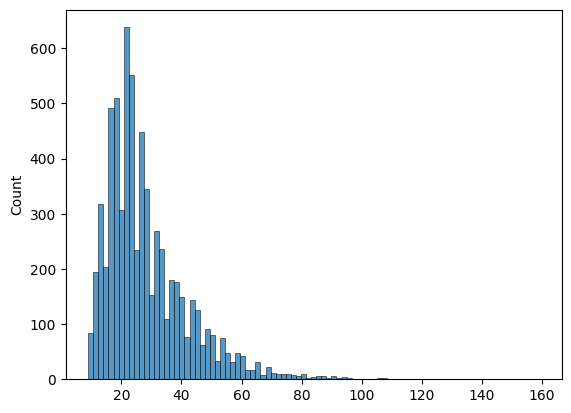

In [17]:
token_counts = []

for _, row in train_data.iterrows():
    text = str(row["Reviews"])  # Ensure the text is converted to a string
    token_count = len(tokenizer.encode(
        text,
        max_length=512,
        truncation=True
    ))
    token_counts.append(token_count)

sns.histplot(token_counts)

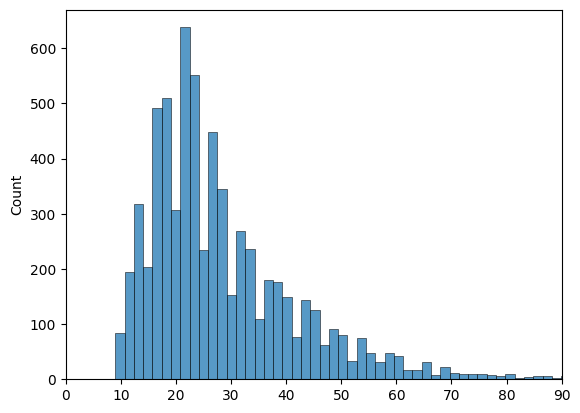

In [18]:
sns.histplot(token_counts)
plt.xlim([0, 90]);

<Axes: ylabel='Count'>

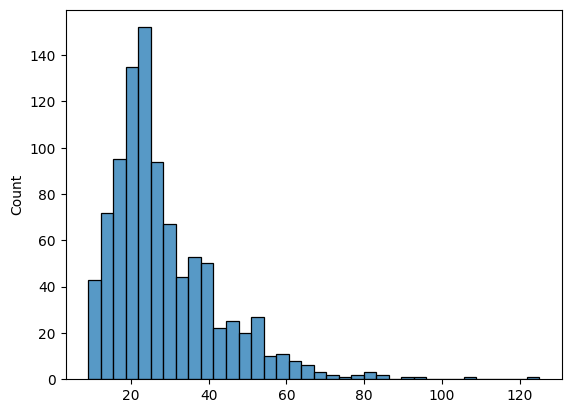

In [19]:
token_counts = []

for _, row in val_data.iterrows():
    text = str(row["Reviews"])  # Ensure the text is converted to a string
    token_count = len(tokenizer.encode(
        text,
        max_length=512,
        truncation=True
    ))
    token_counts.append(token_count)

sns.histplot(token_counts)


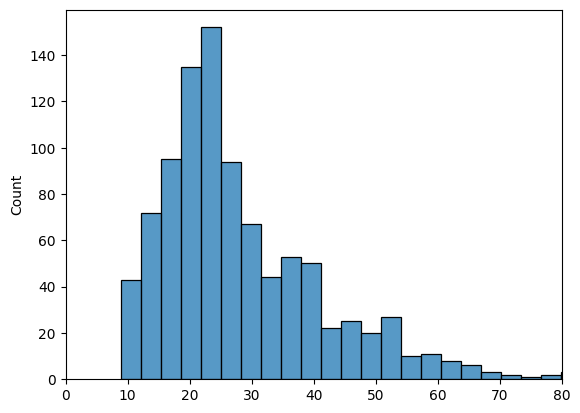

In [20]:
sns.histplot(token_counts)
plt.xlim([0, 80]);

In [21]:
class ClassifierDataset(Dataset):
    def __init__(self, df,tokenizer):
        super(ClassifierDataset, self).__init__()
        self.df = df 
        self.labels = torch.tensor(df.Label.values, dtype=torch.long)
        self.tokenizer = tokenizer
        self.max_length = config.MAX_LEN

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        text = str(self.df.iloc[index]["Reviews"])
        inputs = self.tokenizer(
            text,
            padding=True, 
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        input_ids = inputs["input_ids"].squeeze(0)
        attention_mask = inputs["attention_mask"].squeeze(0)
        labels = self.labels[index]

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }


In [22]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [23]:
class Engine:
    def __init__(self, model, optimizer,scheduler = None):
        self.model = model
        self.optimizer = optimizer
        self.scheduler = scheduler
        
    @staticmethod
    def loss_fn(target, pred):
        loss_fct = nn.CrossEntropyLoss()
        loss = loss_fct(pred,target)
        return loss
    
    @staticmethod
    def compute_metrics(labels, pred):
        y_true = labels.cpu().numpy()
        pred = pred.cpu().numpy()
        y_pred = np.argmax(pred, axis = -1)
        f1 = f1_score(y_true, y_pred, average='weighted')
        return f1
        
    def train(self, train_dataloader,scaler,num_training_steps):
        self.model.train()
        total_training_loss = 0.0
        progress_bar = tqdm(range(num_training_steps))
        for data in train_dataloader:
            input_ids = data["input_ids"].to(config.DEVICE)
            attention_mask = data["attention_mask"].to(config.DEVICE)            
            target = data["labels"].to(config.DEVICE)
            self.optimizer.zero_grad()
            
            with amp.autocast():
                pred = self.model(input_ids, attention_mask)
                loss = self.loss_fn(target,pred)
                
            total_training_loss += loss.item()
            scaler.scale(loss).backward()
            scaler.step(self.optimizer)
            scaler.update()
            if self.scheduler:
                self.scheduler.step()
            progress_bar.update(1)
                
        return total_training_loss / len(train_dataloader)
    
    def evaluate(self,eval_dataloader):
        self.model.eval()
        val_loss = 0
        score = 0.0
        with torch.no_grad():
            for data in tqdm(eval_dataloader):
                input_ids = data["input_ids"].to(config.DEVICE)  
                attention_mask = data["attention_mask"].to(config.DEVICE)              
                target = data["labels"].to(config.DEVICE)  
                
                pred = self.model(input_ids, attention_mask)
                loss = self.loss_fn(target,pred)
                val_loss += loss.item()
                batch_score = self.compute_metrics(target,pred)
                score+= batch_score
             
            score = score / len(eval_dataloader)
            val_loss = val_loss / len(eval_dataloader)
        
        return score, val_loss

In [24]:
# import torch
# import torch.nn as nn
# from transformers import AutoModel, AutoConfig

# class ClassifierModel(nn.Module):
#     def __init__(self):
#         super(ClassifierModel, self).__init__()
#         self.model_config = AutoConfig.from_pretrained(config.MODEL_PATH)
#         self.model = AutoModel.from_pretrained(config.MODEL_PATH, config=self.model_config)
        
#         # Multi-head self attention layer
#         self.attention = nn.MultiheadAttention(
#             embed_dim=self.model_config.hidden_size,
#             num_heads=8,
#             dropout=0.1,
#             batch_first=True
#         )
        
#         # Dense layers
#         self.dense1 = nn.Linear(self.model_config.hidden_size * 2, 512)  # *2 for concatenation with attention
#         self.dense2 = nn.Linear(512, 256)
        
#         # Dropout and normalization
#         self.drop1 = nn.Dropout(p=0.3)
#         self.drop2 = nn.Dropout(p=0.45)
#         self.layer_norm = nn.LayerNorm(256)
        
#         # Output layer
#         self.classifier = nn.Linear(256, config.NUM_CLASSES)
        
#         # Activation
#         self.gelu = nn.GELU()
        
#     def forward(self, input_ids, attention_mask):
#         # Get model outputs
#         outputs = self.model(
#             input_ids=input_ids,
#             attention_mask=attention_mask,
#             return_dict=True
#         )
        
#         # Get sequence output and CLS token
#         sequence_output = outputs.last_hidden_state
#         cls_token = sequence_output[:, 0, :]
        
#         # Apply self-attention
#         attn_output, _ = self.attention(
#             sequence_output,
#             sequence_output,
#             sequence_output,
#             key_padding_mask=~attention_mask.bool()
#         )
        
#         # Global average pooling of attention output
#         avg_pool = torch.mean(attn_output, dim=1)
        
#         # Concatenate CLS token and attention output
#         combined = torch.cat([cls_token, avg_pool], dim=1)
        
#         # Dense layers with dropout
#         x = self.drop1(combined)
#         x = self.dense1(x)
#         x = self.gelu(x)
        
#         x = self.drop2(x)
#         x = self.dense2(x)
#         x = self.gelu(x)
        
#         # Layer normalization
#         x = self.layer_norm(x)
        
#         # Classification layer
#         output = self.classifier(x)
#         return output


# class ClassifierModel(nn.Module):
#     def __init__(self):
#         super(ClassifierModel, self).__init__()
#         self.model_config = AutoConfig.from_pretrained(config.MODEL_PATH)
#         self.model = AutoModel.from_pretrained(config.MODEL_PATH, config=self.model_config)
        
#         # Multi-head self attention with adjusted parameters
#         self.attention = nn.MultiheadAttention(
#             embed_dim=self.model_config.hidden_size,
#             num_heads=12,  # Increased number of heads
#             dropout=0.15,  # Reduced dropout
#             batch_first=True
#         )
        
#         # Additional pooling layer
#         self.max_pool = nn.AdaptiveMaxPool1d(1)
        
#         # Dense layers with adjusted dimensions
#         self.dense1 = nn.Linear(self.model_config.hidden_size * 3, 768)  # *3 for triple concatenation
#         self.dense2 = nn.Linear(768, 384)
        
#         # Adjusted dropout rates
#         self.drop1 = nn.Dropout(p=0.25)
#         self.drop2 = nn.Dropout(p=0.35)
#         self.layer_norm1 = nn.LayerNorm(768)
#         self.layer_norm2 = nn.LayerNorm(384)
        
#         self.classifier = nn.Linear(384, config.NUM_CLASSES)
#         self.gelu = nn.GELU()
        
#     def forward(self, input_ids, attention_mask):
#         outputs = self.model(
#             input_ids=input_ids,
#             attention_mask=attention_mask,
#             return_dict=True
#         )
        
#         sequence_output = outputs.last_hidden_state
#         cls_token = sequence_output[:, 0, :]
        
#         # Apply self-attention
#         attn_output, _ = self.attention(
#             sequence_output,
#             sequence_output,
#             sequence_output,
#             key_padding_mask=~attention_mask.bool()
#         )
        
#         # Multiple pooling strategies
#         avg_pool = torch.mean(attn_output, dim=1)
#         max_pool = torch.max(attn_output, dim=1)[0]
        
#         # Combine all representations
#         combined = torch.cat([cls_token, avg_pool, max_pool], dim=1)
        
#         # Enhanced dense layer processing
#         x = self.drop1(combined)
#         x = self.dense1(x)
#         x = self.layer_norm1(x)
#         x = self.gelu(x)
        
#         x = self.drop2(x)
#         x = self.dense2(x)
#         x = self.layer_norm2(x)
#         x = self.gelu(x)
        
#         output = self.classifier(x)
#         return output
import torch
import torch.nn as nn
from transformers import AutoModel, AutoConfig

class ClassifierModel(nn.Module):
    def __init__(self):
        super(ClassifierModel, self).__init__()
        self.model_config = AutoConfig.from_pretrained(config.MODEL_PATH)
        self.model = AutoModel.from_pretrained(config.MODEL_PATH, config=self.model_config)
        
        # Custom attention layer
        self.attention = nn.MultiheadAttention(
            embed_dim=self.model_config.hidden_size,
            num_heads=8,
            dropout=0.1,
            batch_first=True
        )
        
        # Final classification layers
        self.classifier = nn.Sequential(
            nn.Linear(self.model_config.hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, config.NUM_CLASSES)
        )
        
    def forward(self, input_ids, attention_mask):
        # Get model outputs
        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )
        
        sequence_output = outputs.last_hidden_state  # [batch_size, seq_len, hidden_size]
        
        # Apply self-attention
        attn_output, _ = self.attention(
            sequence_output,
            sequence_output,
            sequence_output,
            key_padding_mask=~attention_mask.bool()
        )
        
        # Get CLS token output (first token)
        cls_output = attn_output[:, 0, :]  # [batch_size, hidden_size]
        
        # Get final classification
        output = self.classifier(cls_output)
        
        return output

In [25]:
history = defaultdict(list)
def run_training(save_model = False):
    train_dataset = ClassifierDataset(train_data,tokenizer)
    val_dataset = ClassifierDataset(val_data,tokenizer)
    train_loader = DataLoader(train_dataset, batch_size = config.BATCH_SIZE,
                              collate_fn=data_collator, shuffle =True, num_workers=2)    
    val_loader = DataLoader(val_dataset, batch_size = config.BATCH_SIZE,
                            collate_fn=data_collator, shuffle=False, num_workers=2)   
    
    set_random_seed(config.SEED)
    model = ClassifierModel()
    model.to(config.DEVICE)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr= config.LR, weight_decay=0.01)
    num_training_steps = config.NUM_EPOCHS * len(train_loader)
    warmup_steps = int(0.1 * num_training_steps)
    
    scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps= 0,
    num_training_steps=num_training_steps,
    )
    eng = Engine(model, optimizer, scheduler)
    scaler = amp.GradScaler()
    early_stopping_iter = 5
    early_stopping_counter = 0
    best_score = 0.0
    for epoch in range(config.NUM_EPOCHS):
        train_loss = eng.train(train_loader,scaler,num_training_steps)
        val_score,val_loss = eng.evaluate(val_loader)
        
        print(f" Epoch: {epoch + 1} | Training_loss: {round(train_loss,4)} | Val_loss: {round(val_loss,4)} | Val_f1: {round(val_score,4)}")
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if val_score > best_score:
            best_score = val_score
            early_stopping_counter = 0
            
            if save_model:
                torch.save(model.state_dict(),f"attention_on_bert_model.bin")
        else:
            early_stopping_counter +=1
            
        if early_stopping_counter > early_stopping_iter:
            break
            
    del model
    gc.collect()
            
    return round(best_score,5)

In [26]:
score =run_training(save_model = True)
print(f"Best f1 Score: {score}")

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

  0%|          | 0/3135 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

 Epoch: 1 | Training_loss: 0.5009 | Val_loss: 0.2663 | Val_f1: 0.8983


  0%|          | 0/3135 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

 Epoch: 14 | Training_loss: 0.0032 | Val_loss: 0.3838 | Val_f1: 0.923


  0%|          | 0/3135 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

 Epoch: 15 | Training_loss: 0.0033 | Val_loss: 0.374 | Val_f1: 0.9288
Best f1 Score: 0.931


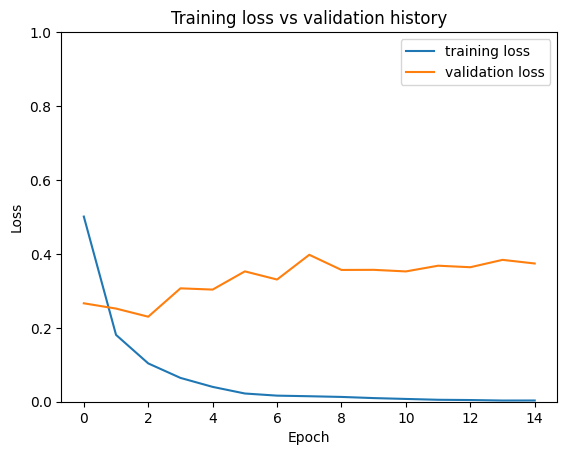

In [27]:
plt.plot(history['train_loss'], label='training loss')
plt.plot(history['val_loss'], label='validation loss')

plt.title('Training loss vs validation history')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1]);

In [28]:
model = ClassifierModel()

In [29]:
model_path = f"/kaggle/working/attention_on_bert_model.bin"
model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [30]:
model.to(config.DEVICE)

ClassifierModel(
  (model): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ElectraSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), ep

In [31]:
# test_data = pd.read_csv("hf://datasets/kcrl/Gadet_Review_Dataset/" + splits["test"])

In [32]:
test_data.head()

,Reviews,category,Label,Length,Word Count
3436,কনডম কিনে খুব অনুতপ্ত। নকল মাল 😔😔 দাম আর কোয়া...,adult_items,0,63,13
2492,ওয়াটার ব্যাগ অরিজিনাল মনে হচ্ছে। অন্যরা নিতে ...,medical_kits,3,93,14
4179,বেস কয়েক টা পণ্য সামগ্রিই কিনেছি এর মধ্যে থার্...,medical_kits,1,95,18
1282,চমৎকার একটি প্রোডাক্ট। খুব উন্নত মানের প্রোডাক...,body_fitness,4,93,16
8862,"আমি ঠিক বলতে পারছি না কেন এমন হচ্ছে, মূলত মেডি...",medicines,1,79,15


In [33]:
test_dataset = ClassifierDataset(test_data, tokenizer)

In [34]:
from torch.utils.data import DataLoader
test_dataloader = DataLoader(
    test_dataset, batch_size=64, collate_fn=data_collator
)

In [35]:
model.eval()
pred = []
for batch in test_dataloader:
    batch = {k: v.to(config.DEVICE) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(input_ids = batch["input_ids"],attention_mask = batch["attention_mask"])
        batch_preds = torch.argmax(outputs, dim=-1)
        pred.extend(batch_preds.cpu().numpy().tolist()) 

In [36]:
y_true = test_data.Label.values
y_pred = pred

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(y_true, y_pred))

[[420  18   2   0   0]
 [ 12 283  17   1   0]
 [  2  27 263  12   1]
 [  0   1  29 365   3]
 [  0   0   0  14 434]]


In [38]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)

# Print the classification report
print("Classification Report:\n", classification_report(y_true, y_pred))

# Print the confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

# Calculate individual metrics for weighted and macro averages
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
macro_f1 = f1_score(y_true, y_pred, average='macro')

weighted_precision = precision_score(y_true, y_pred, average='weighted')
macro_precision = precision_score(y_true, y_pred, average='macro')

weighted_recall = recall_score(y_true, y_pred, average='weighted')
macro_recall = recall_score(y_true, y_pred, average='macro')

accuracy = accuracy_score(y_true, y_pred)

print("Model: Attention on BanglaBERT (Seed: 1)")

# Print metrics
print("Weighted F1 Score:", weighted_f1)
print("Macro F1 Score:", macro_f1)
print("Weighted Precision:", weighted_precision)
print("Macro Precision:", macro_precision)
print("Weighted Recall:", weighted_recall)
print("Macro Recall:", macro_recall)
print("Accuracy:", accuracy)

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96       440
           1       0.86      0.90      0.88       313
           2       0.85      0.86      0.85       305
           3       0.93      0.92      0.92       398
           4       0.99      0.97      0.98       448

    accuracy                           0.93      1904
   macro avg       0.92      0.92      0.92      1904
weighted avg       0.93      0.93      0.93      1904

Confusion Matrix:
 [[420  18   2   0   0]
 [ 12 283  17   1   0]
 [  2  27 263  12   1]
 [  0   1  29 365   3]
 [  0   0   0  14 434]]
Model: Attention on BanglaBERT (Seed: 1)
Weighted F1 Score: 0.9274890856851659
Macro F1 Score: 0.9200698091167
Weighted Precision: 0.9282904354983266
Macro Precision: 0.9191146998359893
Weighted Recall: 0.9269957983193278
Macro Recall: 0.9213658636561867
Accuracy: 0.9269957983193278


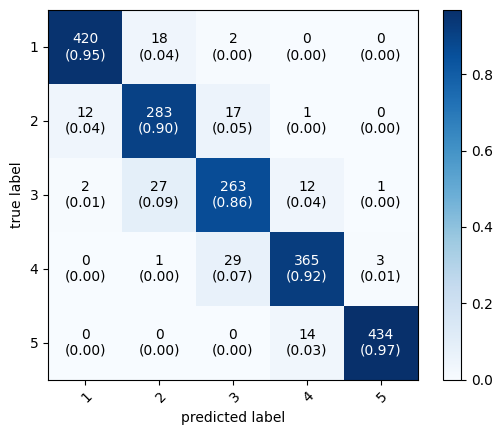

In [39]:
import torch
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_confusion_matrix
from torchmetrics import ConfusionMatrix
y_pred = torch.tensor(y_pred)
y_true = torch.tensor(y_true)

cmat = ConfusionMatrix(task="multiclass", num_classes = 5)
confusion_matrix = cmat(y_pred, y_true)

fig, ax = plot_confusion_matrix(conf_mat=confusion_matrix.cpu().numpy(),
                                class_names=[1, 2, 3, 4, 5],
                                show_normed=True,
                                colorbar=True)

# Rotate the x-axis labels
plt.xticks(rotation=45, ha="right", rotation_mode="anchor")

# Show the plot
plt.show()